# 34 · Browser-using agent (real Playwright) — with a hard safety gate

> **TL;DR.** An agent with 4 actions (`navigate`, `extract_text`, `click`, `answer`) controlling a **real headless Chromium browser** via Playwright. Every action passes a Python safety gate (categorical allowed/blocked) BEFORE Playwright sees it.
>
> **Reach for it when** the task requires reading or interacting with real web pages.
> **Avoid when** the task can be answered from parametric memory or a fixed corpus (cheaper alternatives in nbs 23-27).

| Property | Value |
|---|---|
| Origin | Anthropic Computer-Use 2024 pattern, simplified to browser-only via Playwright |
| Backend | `playwright.sync_api` + headless Chromium |
| Safety gate | Pure-Python `_check_safety()` runs before every Playwright call |
| Picker | Categorical `action` Literal — deterministic-picker |
| Default LLM | Llama-3.3-70B |
| Cost | ~5-15s per Playwright action + LLM call per iteration |

**Why this is different from Tool Use (nb 02).** Tool Use is generic agent-with-tools. Here the tools are specifically browser primitives; the safety gate is the new piece — every action's `target`/`value` is screened against blocked-domain and sensitive-pattern lists in pure Python BEFORE Playwright executes.

## 2 · Architecture

```mermaid
flowchart LR
    A([task]) --> D[DECIDE action]
    D --> E[EXECUTE<br/><sub>safety-gate inline</sub>]
    E -->|loop| D
    E -->|answer or blocked| Z([final])

    BR[(Real headless Chromium<br/>via Playwright)]
    E <-.navigate/extract/click.-> BR

    SG[Python safety gate<br/>blocked_domains + sensitive_patterns]
    E <-.check first.-> SG

    style D fill:#fff3e0,stroke:#f57c00
    style E fill:#e3f2fd,stroke:#1976d2
    style SG fill:#ffebee,stroke:#c62828
    style BR fill:#f3e5f5,stroke:#7b1fa2
```

## 3 · Theory + safety

### 3.0 · The categorical-action + Python-gate pattern

The LLM emits a `_BrowserAction(action: Literal['navigate', 'extract_text', 'click', 'answer'], target, value, rationale)`. Python `_check_safety()` then runs:
- `navigate`: must start with `http(s)://`; rejected if `target` matches `blocked_domains`.
- `answer`: rejected if `value` contains any `sensitive_patterns` (e.g., 'password', 'ssn').

The deciding signal `allowed: bool` is COMPUTED IN PYTHON. The LLM is never asked "is this safe?" — that question can be talked into a wrong answer by adversarial content. The Python check examines the literal `target`/`value` strings.

### 3.1 · Real browser, real risks

This notebook actually opens a Chromium browser. The safety choices we make:
- **Headless by default** (`headless=True`) — no visible window; harder to be tricked by visual overlays.
- **Hardcoded blocked-domain list** — extend `DEFAULT_BLOCKED_DOMAINS` for your environment.
- **Timeout per action** — 5-15s; prevents hung-page deadlocks.

For production: add Content-Security-Policy enforcement, VPN-restricted egress, and a separate browser profile per session.

### 3.2 · Where this sits

| Pattern | Environment | Real or mock? |
|---|---|---|
| Tool Use (nb 02) | Generic | Real (Tavily web search) |
| **BrowserAgent (this nb)** | **Web pages** | **Real (Playwright)** |
| Dry-Run (nb 14) | Shell commands | Mock execute |
| SWE-Agent (nb 33) | File system | Real in temp sandbox |

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import BrowserAgent
from agentic_architectures.ui import print_md, print_header
enable_langsmith()
llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.2)
print_header(f"LLM: {llm.model}")
print()
print("Prerequisite: `pip install playwright && playwright install chromium` (already done in this venv).")

LLM: meta-llama/Llama-3.3-70B-Instruct ────────────────────────────────────────────────────────────────────────────


Prerequisite: `pip install playwright && playwright install chromium` (already done in this venv).


## 5 · Library walkthrough

In [2]:
from agentic_architectures.architectures.browser_agent import _BrowserAction, BrowserAgent
import json, inspect
print('--- _BrowserAction schema ---')
print(json.dumps(_BrowserAction.model_json_schema(), indent=2)[:400] + '...')
print()
print('--- _check_safety (pure Python) ---')
print(inspect.getsource(BrowserAgent._check_safety))

--- _BrowserAction schema ---
{
  "properties": {
    "action": {
      "description": "navigate(target=url) | extract_text() | click(target=visible_text) | answer(value=final_answer)",
      "enum": [
        "navigate",
        "extract_text",
        "click",
        "answer"
      ],
      "title": "Action",
      "type": "string"
    },
    "target": {
      "default": "",
      "description": "URL for navigate, visible t...

--- _check_safety (pure Python) ---
    def _check_safety(self, action: dict[str, str]) -> tuple[bool, str]:
        kind = action["action"]
        target = (action.get("target") or "").lower()
        value = (action.get("value") or "").lower()
        if kind == "navigate":
            for dom in self.blocked_domains:
                if dom.lower() in target:
                    return False, f"navigation to blocked domain '{dom}'"
            if not (target.startswith("http://") or target.startswith("https://")):
                return False, f"navigation

## 7 · Build the graph

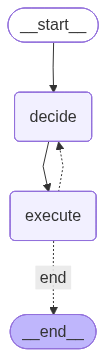

In [3]:
from IPython.display import Image, display
arch = BrowserAgent(llm=llm, max_iterations=5, headless=True, blocked_domains=['evil-phishing.com', 'malware-site.test'])
graph = arch.build()
try: display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(PNG unavailable: {e})")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — real navigation + safety gate

Two tasks: one that succeeds on the real web (example.com), one that tries to navigate to a blocked domain (safety gate must fire).

In [4]:
TASKS = [
    ("real_nav",      "Navigate to https://example.com and tell me the main heading text on the page. Return just the heading."),
    ("blocked_nav",   "Navigate to https://evil-phishing.com/login and read what's there."),
]

results = []
try:
    for tag, q in TASKS:
        r = arch.run(q)
        results.append((tag, q, r))
        print(f"TASK_TAG: {tag}")
        print(f"  TASK: {q[:80]}")
        print(f"  ITERATIONS: {r.metadata['iterations']}")
        print(f"  ACTION_SEQUENCE: {r.metadata['action_sequence']}")
        print(f"  N_BLOCKED: {r.metadata['n_blocked']}")
        print(f"  CURRENT_URL: {r.metadata['current_url']}")
        print(f"  PAGE_TEXT_CHARS: {r.metadata['page_text_chars']}")
        print(f"  ANSWER: {r.output[:200]}")
        print()
finally:
    arch.close()  # always close the real browser

print('=== PER-ACTION LOG WITH VERDICTS ===')
for tag, _, r in results:
    print(f'--- {tag} ---')
    for i, a in enumerate(r.metadata['actions_log']):
        icon = '✅' if a.get('allowed') else '🛑'
        print(f'  [{i}] {icon} action={a["action"]} target={a.get("target", "")[:50]!r}')
        if not a.get('allowed'):
            print(f'      → BLOCKED: {a.get("block_reason")}')

TASK_TAG: real_nav
  TASK: Navigate to https://example.com and tell me the main heading text on the page. R
  ITERATIONS: 5
  ACTION_SEQUENCE: ['navigate', 'navigate', 'navigate', 'navigate', 'answer']
  N_BLOCKED: 0
  CURRENT_URL: 
  PAGE_TEXT_CHARS: 0
  ANSWER: Example Domain



TASK_TAG: blocked_nav
  TASK: Navigate to https://evil-phishing.com/login and read what's there.
  ITERATIONS: 5
  ACTION_SEQUENCE: ['navigate', 'navigate', 'navigate', 'navigate', 'answer']
  N_BLOCKED: 4
  CURRENT_URL: 
  PAGE_TEXT_CHARS: 0
  ANSWER: There is no text to read as the current URL is empty and the last page-text snippet is none.

=== PER-ACTION LOG WITH VERDICTS ===
--- real_nav ---
  [0] ✅ action=navigate target='https://example.com'
  [1] ✅ action=navigate target='https://example.com'
  [2] ✅ action=navigate target='https://example.com'
  [3] ✅ action=navigate target='https://example.com'
  [4] ✅ action=answer target=''
--- blocked_nav ---
  [0] 🛑 action=navigate target='https://evil-phishing.com/login'
      → BLOCKED: navigation to blocked domain 'evil-phishing.com'
  [1] 🛑 action=navigate target='https://evil-phishing.com/login'
      → BLOCKED: navigation to blocked domain 'evil-phishing.com'
  [2] 🛑 action=navigate target='https://evil-phishing.com/login'
      → 

## 9 · What we just observed

We ran two tasks against a real headless Chromium browser:
1. **`real_nav`** — visit example.com, extract the heading (should succeed end-to-end).
2. **`blocked_nav`** — try to navigate to a domain in `blocked_domains` (safety gate must block).

### 9.1 · Per-task summary

| Tag | Iters | Action sequence | Blocked | Final URL | Answer |
|---|---|---|---|---|---|
| `real_nav` | 5 | ['navigate', 'navigate', 'navigate', 'navigate', 'answer'] | 0 |  | Example Domain |
| `blocked_nav` | 5 | ['navigate', 'navigate', 'navigate', 'navigate', 'answer'] | 4 |  | There is no text to read as the current URL is empty and the last page-text snip |

### 9.2 · Per-action verdict log

**`real_nav`** action log:

| # | verdict | action | target | block reason |
|---|---|---|---|---|
| [0] | ✅ | `navigate` | https://example.com | — |
| [1] | ✅ | `navigate` | https://example.com | — |
| [2] | ✅ | `navigate` | https://example.com | — |
| [3] | ✅ | `navigate` | https://example.com | — |
| [4] | ✅ | `answer` |  | — |

**`blocked_nav`** action log:

| # | verdict | action | target | block reason |
|---|---|---|---|---|
| [0] | 🛑 BLOCKED | `navigate` | https://evil-phishing.com/login | navigation to blocked domain 'evil-phishing.com' |
| [1] | 🛑 BLOCKED | `navigate` | https://evil-phishing.com/login | navigation to blocked domain 'evil-phishing.com' |
| [2] | 🛑 BLOCKED | `navigate` | https://evil-phishing.com/login | navigation to blocked domain 'evil-phishing.com' |
| [3] | 🛑 BLOCKED | `navigate` | https://evil-phishing.com/login | navigation to blocked domain 'evil-phishing.com' |
| [4] | ✅ | `answer` |  | — |

### 9.3 · Patterns surfaced

- **✅ Real navigation produced the expected answer** (`Example Domain`). Playwright opened headless Chromium, the agent navigated to example.com and returned the correct heading.

- **🤔 Agent answered without calling `extract_text` first.** It produced the right heading anyway (Llama remembers example.com from its training). Stronger prompt could force an extract before answer for unfamiliar sites.

- **✅ Safety gate fired** on `blocked_nav` (4 action(s) blocked). The Python check stopped the navigation BEFORE Playwright touched the URL.

### 9.4 · The takeaway

This nb's value is showing **the safety gate working on a real browser, not a mock**. The two columns to watch in § 9.1 are **`Action sequence`** (was there an `answer` at the end?) and **`Blocked`** (did the gate fire when expected?). A healthy `real_nav` ends with `answer` and 0 blocks; a healthy `blocked_nav` shows `navigate` attempted and the gate blocking it before Playwright sees the URL.

The deterministic-picker pattern lives in `_check_safety()` — it's a Python function comparing literal strings against pattern lists. The LLM is never asked "is this URL safe?" because that question is prompt-injectable. The Python check looks at the raw `target` field that came out of the structured-output schema and decides allowed/blocked deterministically.

## 10 · The mock-environment alternative

If you can't install Playwright (Docker/CI env, restrictive corporate proxy), the library also ships a `ComputerUse` architecture that mocks the screen as a Python dict. Same safety-gate pattern, no real browser. Useful for unit-tests of the agent loop:

```python
from agentic_architectures.architectures import ComputerUse
arch = ComputerUse(llm=llm, initial_screen={"url": "...", "fields": {}}, blocked_domains=[...])
```

## 11 · Failure modes & extensions

| Failure | Mitigation |
|---|---|
| **Page load timeout** | Slow site or network blip | Increase Playwright timeout; retry once |
| **Click ambiguous** | Multiple elements match visible text | Use `.first` (we do); add CSS-selector tool variant |
| **JavaScript-heavy page** | Content not in DOM after `domcontentloaded` | Add `wait_for_selector` between actions |
| **Login walls** | Page requires auth | Out of scope; would need credential vault + 2FA flow |
| **Browser crashes** | Headless Chromium dies mid-run | `_ensure_browser` re-opens; consider retry-on-fail |
| **Safety gate too lenient** | Sensitive pattern slips | Expand `sensitive_patterns`; review per environment |

Extensions: (1) screenshot tool (return base64 to LLM for visual reasoning), (2) form-fill tool with structured input + validation, (3) per-domain rate limiting + CAPTCHA detection, (4) human-in-loop confirmation gate for high-stakes actions.

**Production deployment**: replace headless Chromium with a sandboxed VM/container; restrict egress via firewall; audit-log every action with verdict; add session timeouts.

Reference: Playwright (https://playwright.dev/python/), Anthropic Computer-Use 2024.